## 0. Setup

In [2]:
# built-in
import datetime
import os
import glob
# external
import numpy as np
import pandas as pd
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
# from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, matthews_corrcoef #, accuracy_score

import torch
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.tensorboard import SummaryWriter
from torch.utils.data import DataLoader, TensorDataset

#### Setup Desired Hyper-parameters

In [ ]:
RAND_NUM = 25

# pure or majority
WINDOW_TYPE = "pure"
WINDOW_SIZE = 128
STRIDE = 32

LEARNING_RATE = 0.001
EPOCHS = 10

CONFIG_NAME = f"{str.capitalize(WINDOW_TYPE[0])}W{WINDOW_SIZE}_S{STRIDE}_LR{LEARNING_RATE}_E{EPOCHS}"
print(CONFIG_NAME)

PW128_S32_LR0.001


## 1. Data setup

### 1a. Load in sEMG data from UCI ML Repository

In [9]:
def preprocess_emg_folder(folder_path):
    # Grab all subjects    
    folder_list = glob.glob(os.path.join(folder_path, "*/"))
    full_features = []
    full_lables = []
    for folder in folder_list:
        # Grab emg data files
        file_list = glob.glob(os.path.join(folder, "*.txt"))
        for file in file_list:
            # Load data: Time (0), Channels (1-8), Class (9)
            df = pd.read_csv(file, sep='\s+')
            
            # 1. Feature Extraction: (1-8)
            features = df.iloc[:, 1:9].values 
            
            # 2. Class Extraction: (9)
            labels = df.iloc[:, 9].values

            # 3. Clean Data: Remove unmarked data and palm data
            valid_indices = (labels != 0) & (labels!= 7)
            features = features[valid_indices]
            labels = labels[valid_indices]
            
            # Shift labels 1-6 -> 0-5 for NN compatibility
            labels = labels - 1
            
            # append to full list of features & labels
            full_features.extend(features)
            full_lables.extend(labels)
    return full_features, full_lables

X_train_raw, y_train_raw = preprocess_emg_folder('./Data/train')
X_test_raw, y_test_raw = preprocess_emg_folder('./Data/test')

### 1b. Normalize + Clean data

In [10]:
def cleanNormalizeData(X, y):
    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    # 1. Combine into a temporary DataFrame to keep rows aligned
    temp_df = pd.DataFrame(X)
    temp_df['label'] = y

    # 2. Drop any row that has a NaN in either the features or the label
    clean_df = temp_df.dropna()

    # 3. Extract back into X and y
    X = clean_df.drop(columns=['label']).values
    y = clean_df['label'].values
    
    return X, y

X_train_raw, y_train_raw = cleanNormalizeData(X_train_raw, y_train_raw)
X_test_raw, y_test_raw = cleanNormalizeData(X_test_raw, y_test_raw)

### Sanity Check: Data properly loaded in + split

TRAINING data shape: (1168557, 8)
TESTING data shape: (330497, 8)


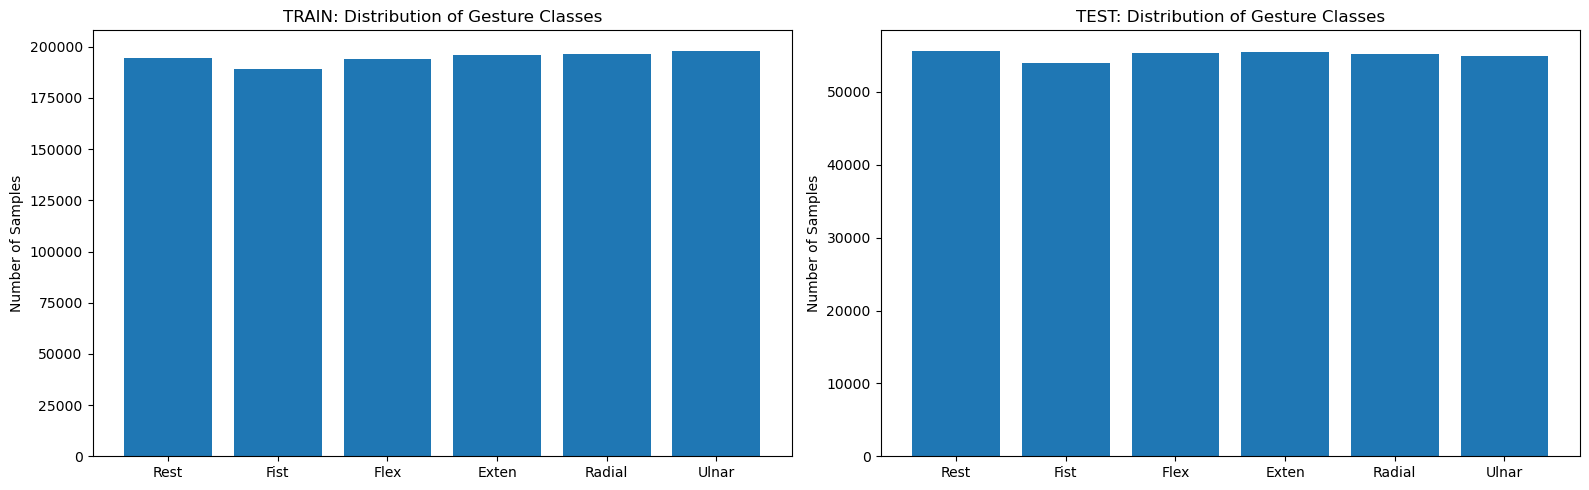

In [11]:
def viewData(X_train, X_test, y_train, y_test):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

    ax1.hist(y_train, bins=range(7), align='left', rwidth=0.8)
    ax1.set_xticks(range(6))
    ax1.set_xticklabels(['Rest', 'Fist', 'Flex', 'Exten', 'Radial', 'Ulnar'])
    ax1.set_title("TRAIN: Distribution of Gesture Classes")
    ax1.set_ylabel("Number of Samples")

    ax2.hist(y_test, bins=range(7), align='left', rwidth=0.8)
    ax2.set_xticks(range(6))
    ax2.set_xticklabels(['Rest', 'Fist', 'Flex', 'Exten', 'Radial', 'Ulnar'])
    ax2.set_title("TEST: Distribution of Gesture Classes")
    ax2.set_ylabel("Number of Samples")

    print(f"TRAINING data shape: {X_train.shape}")
    print(f"TESTING data shape: {X_test.shape}")
    plt.tight_layout()
    plt.show()

viewData(X_train_raw, X_test_raw, y_train_raw, y_test_raw)

### 1c. Time-Window Data

In [ ]:
# only accepts PERFECT WINDOWS (i.e doesn't fill with dumby 0's)
def create_windows_pure(X, y, window_size, stride):
    X_win = []
    y_win = []
    loss_data = 0
    for i in range(0, len(y) - window_size + 1, stride):
        X_temp_window = X[i : i + window_size] 
        y_temp_window = y[i : i + window_size] 
        perfect, jump_val = isPure_window(y_temp_window)
        
        if not perfect:
            loss_data += 1
            # INCOMPLETE, not needed with data this large.
            # might be helpful with FT on user data
            # jump by index instead of stride to not waste data 
            continue
        
        # We transpose so shape becomes (8, WINDOW_SIZE) instead of (WINDOW_SIZE, 8)
        X_win.append(X_temp_window.T) 
        y_win.append(y[i])
    print(f"Data Loss to impure windows: {loss_data}")
    return np.array(X_win), np.array(y_win)


def isPure_window(y_win):
    prev = y_win[0]
    for i in range(len(y_win)):
        if y_win[i] != prev:
            return False, i
        else:
            prev = y_win[i]
    
    return True, 0  


def create_windows_majority(X, y, window_size, stride):
    X_win = []
    y_win = []
    lost_data = 0
    for i in range(0, len(y) - window_size + 1, stride):
        X_temp_window = X[i : i + window_size] 
        y_temp_window = y[i : i + window_size] 
        label = majorityClass_window(y_temp_window)
        
        if label == 0:
            lost_data += 1
            continue
        
        # We transpose so shape becomes (8, WINDOW_SIZE) instead of (WINDOW_SIZE, 8)
        X_win.append(X_temp_window.T) 
        y_win.append(label)
    print(f"Data Loss to impure windows: {lost_data}")
    return np.array(X_win), np.array(y_win)


def majorityClass_window(y_win):
    counts = np.zeros(7)
    size = len(y_win)

    for val in y_win:
        counts[int(val)] += 1
    

    majLabel_idx = counts.argmax()

    if(counts[majLabel_idx] > size/2):
        return majLabel_idx
    # Not majority, FAIL IT
    return 0  

def create_windows_last(data, window_size, stride):
    pass

if WINDOW_TYPE=='pure':
    print("Creating PURE Windowed TRAINING data")
    X_train, y_train = create_windows_pure(X_train_raw, y_train_raw, window_size=WINDOW_SIZE, stride=STRIDE)
    print("Creating PURE Windowed TESTING data")
    X_test, y_test = create_windows_pure(X_test_raw, y_test_raw, window_size=WINDOW_SIZE, stride=STRIDE)
elif WINDOW_TYPE=='majority':
    print("Creating MAJORITY Windowed TRAINING data")
    X_train, y_train = create_windows_majority(X_train_raw, y_train_raw)
    print("Creating MAJORITY Windowed TESTING data")
    X_test, y_test = create_windows_majority(X_test_raw, y_test_raw)
else: 
    print("NOT a valid window type.")
    print("Please set WINDOW_TYPE to \'pure\' OR \'majority\'")

Creating PURE Windowed TRAINING data
Data Loss to impure windows: 2669
Creating PURE Windowed TESTING data
Data Loss to impure windows: 755


### Sanity Check: Data properly Windowed

TRAINING data shape: (33845, 8, 128)
TESTING data shape: (9570, 8, 128)


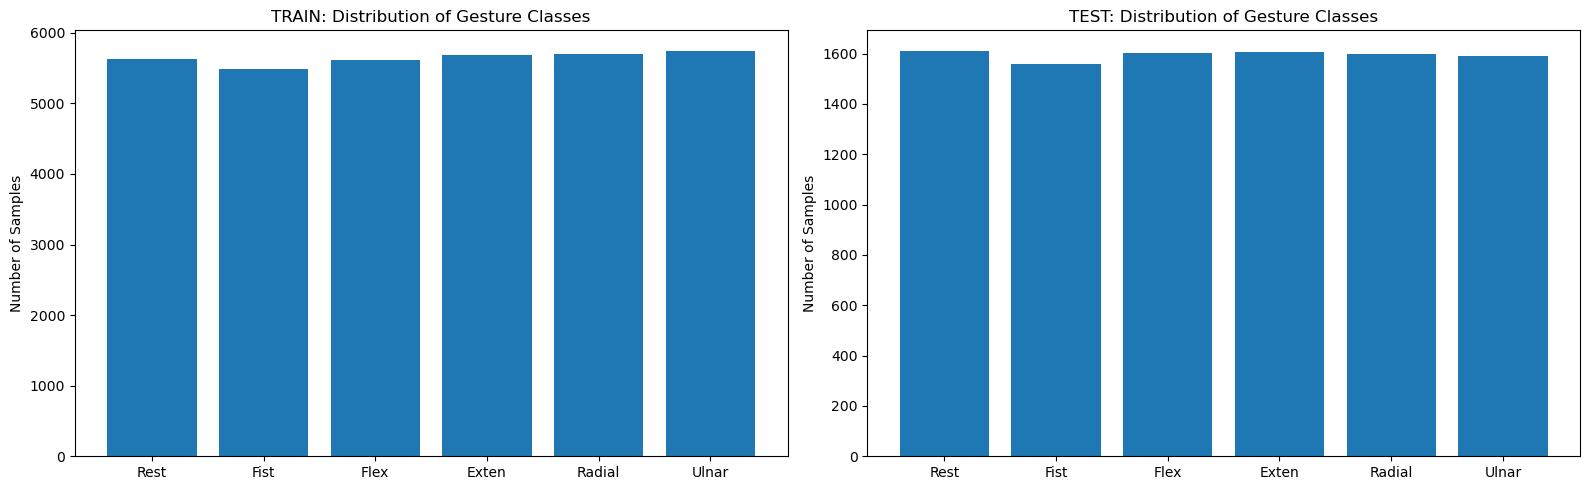

In [13]:
viewData(X_train, X_test, y_train, y_test)

## 2. Setup Model Training

### 2a. Set up layers for CNN

In [14]:
class SimpleEMGFANet(nn.Module):
    def __init__(self, num_classes=6):
        super(SimpleEMGFANet, self).__init__()
        
        # Layer 1: Look for local patterns across the 8 channels
        # Input shape: (Batch, 8, Window_Size)
        # 8 due to the 8 channels of actual input data
        # 32 being a simple power of 2, big enough to capture complexity, small enough for laptop lol
        # 3 length of "filter" itself, smaller given high noise data like EMG
        # 1 gives data length same after convolution
        self.conv1 = nn.Conv1d(in_channels=8, out_channels=32, kernel_size=3, padding=1)
        
        # Layer 2: Deeper features
        # same as above, but with a second layer lol
        # higher scale given # of outputs from prev
        self.conv2 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        
        # Layer 3: Channel Attention (The 'Adaptable' part of FANet)
        # Effictivly maps sensor vars to action
        # Ex: association between high activity in sensor 1 & 2 and fist gesture
        self.attention = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Conv1d(64, 16, 1),
            nn.ReLU(),
            nn.Conv1d(16, 64, 1),
            nn.Sigmoid()
        )
        
        # Final Classifier
        self.fc = nn.Linear(64, num_classes)
    
    # function to allow forward pass through to begin training
    def forward(self, x):
        # 1. Feature Extraction
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        
        # 2. Apply Attention
        weights = self.attention(x)
        x = x * weights
        
        # 3. Global Average Pooling (reduces time dimension to 1)
        x = torch.mean(x, dim=2) 
        
        # 4. Classify
        x = self.fc(x)
        return x


### 2b. Initialize Model + Loss Function + Optimizer

In [15]:
model = SimpleEMGFANet(num_classes=6)
device = torch.device("cpu")
model.to(device)
criterion = nn.CrossEntropyLoss()

# Optimizer to update actual weights of NN & MIN loss
# Adam specifically well adept to not geting stuck in local mins
# tracks velocity of weighting updates, allows to curve change if fickle
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

### 2c. Train Loader Setup

In [16]:
# Wrap processed NumPy arrays into TensorDataset
# X_train: (Samples, 8, WINDOW_SIZE)
# y_train: (Samples,)
train_data_tensor = TensorDataset(
    torch.from_numpy(X_train).float(), 
    torch.from_numpy(y_train).long()
)
train_loader = DataLoader(
    train_data_tensor, 
    batch_size=32, 
    shuffle=True
)

test_data_tensor = TensorDataset(
    torch.from_numpy(X_test).float(), 
    torch.from_numpy(y_test).long()
)
test_loader = DataLoader(
    test_data_tensor, 
    batch_size=32, 
    shuffle=True
)

# Check the first batch
data_iter = iter(train_loader)
images, labels = next(data_iter)
print(images.shape) # Should be [32, 8, WINDOW_SIZE]

torch.Size([32, 8, 128])


#### TensorBoard Reporting Setup

In [18]:
%load_ext tensorboard

tensorboard_log_dir = os.path.join("logs", datetime.datetime.now().strftime("%Y%m%d-%H%M"))
writer = SummaryWriter(tensorboard_log_dir)

## 3. Train

### 3a. Training Loop

In [19]:
def trainCNN_EMG(epochs: int):
    train_losses = []
    test_losses = []

    for epoch in range(epochs):
        # --- TRAIN ---
        model.train() 
        total_loss = 0.0
        for inputs, labels in train_loader:
            # Move data to the same device as the model
            inputs, labels = inputs.to(device), labels.to(device)
            # 1. Zero the gradients (clear prev memory)
            optimizer.zero_grad()
            # 2. Forward pass: Compute predicted outputs
            outputs = model(inputs)
            # 3. Calculate loss
            # using Cross Entropy Loss
            loss = criterion(outputs, labels)
            # 4. Backward pass: Compute gradient of the loss with respect to model parameters
            loss.backward()
            # 5. Perform single optimization step (parameter update)
            # using Adam
            optimizer.step()
            
            total_loss += loss.item()
        avg_train_loss = total_loss / len(train_loader)
        
        # --- TEST ---
        model.eval() 
        total_test_loss = 0.0
        with torch.no_grad(): 
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                total_test_loss += loss.item()
        avg_test_loss = total_test_loss / len(test_loader)
        
        # --- LOG ---
        train_losses.append(avg_train_loss)
        test_losses.append(avg_test_loss)
        print(f"Epoch [{epoch+1}/{epochs}], TRAIN Loss: {avg_train_loss:.4f}")
        print(f"Epoch [{epoch+1}/{epochs}], TEST  Loss: {avg_test_loss:.4f}")
        # WRITER TO TENSORBOARD LOG
        # Write to param specific 
        writer.add_scalars(
        f"Loss/Train/Test_{CONFIG_NAME}",
        {"TRAIN": avg_train_loss, "TEST": avg_test_loss},
        epoch
        )
        # Write to MASTER 
        writer.add_scalars(
            f"Loss/Test",
            {f"{CONFIG_NAME}": avg_test_loss},
            epoch
        )

    print("Finished Training")
    return train_losses, test_losses

train_loss, test_loss = trainCNN_EMG(epochs=EPOCHS)


Epoch [1/10], TRAIN Loss: 0.6763
Epoch [1/10], TEST  Loss: 0.5672
Epoch [2/10], TRAIN Loss: 0.4418
Epoch [2/10], TEST  Loss: 0.5459
Epoch [3/10], TRAIN Loss: 0.3969
Epoch [3/10], TEST  Loss: 0.5193
Epoch [4/10], TRAIN Loss: 0.3602
Epoch [4/10], TEST  Loss: 0.5293
Epoch [5/10], TRAIN Loss: 0.3234
Epoch [5/10], TEST  Loss: 0.5425
Epoch [6/10], TRAIN Loss: 0.3034
Epoch [6/10], TEST  Loss: 0.5198
Epoch [7/10], TRAIN Loss: 0.2851
Epoch [7/10], TEST  Loss: 0.6370
Epoch [8/10], TRAIN Loss: 0.2700
Epoch [8/10], TEST  Loss: 0.5106
Epoch [9/10], TRAIN Loss: 0.2550
Epoch [9/10], TEST  Loss: 0.5273
Epoch [10/10], TRAIN Loss: 0.2422
Epoch [10/10], TEST  Loss: 0.5430
Finished Training


### 3b. Save Model

In [20]:
MODELPATH = os.path.join("models", f"CNN-FANET_{CONFIG_NAME}_E{EPOCHS}.pth")
torch.save(model.state_dict(), MODELPATH)

## 4. Evaluate Model

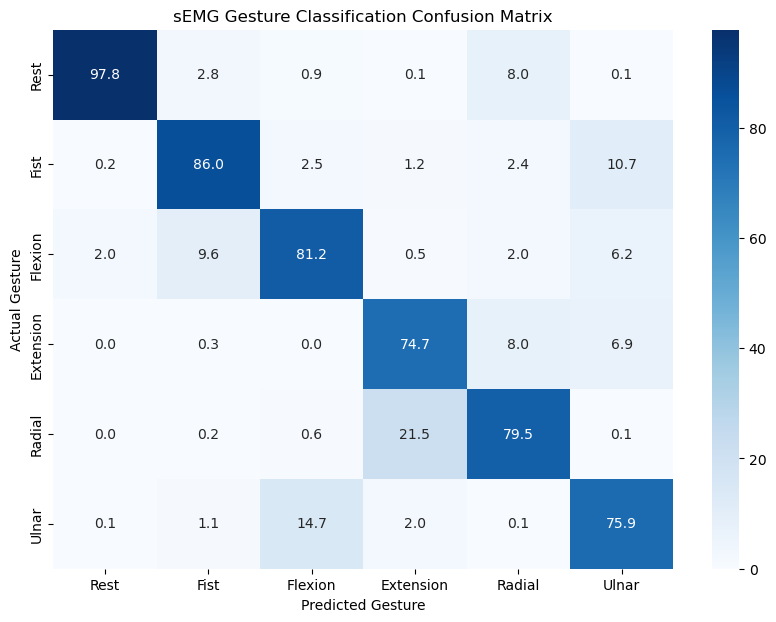

MCC: 0.7847
              precision    recall  f1-score   support

        Rest       0.98      0.89      0.93      1612
        Fist       0.86      0.82      0.84      1559
     Flexion       0.81      0.80      0.81      1602
   Extension       0.75      0.85      0.79      1607
      Radial       0.79      0.74      0.77      1600
       Ulnar       0.76      0.82      0.79      1590

    accuracy                           0.82      9570
   macro avg       0.82      0.82      0.82      9570
weighted avg       0.83      0.82      0.82      9570



In [23]:
def evaluate_model(model, test_loader):
    model.eval()  # Set model to evaluation mode
    all_preds = []
    all_labels = []
    with torch.no_grad(): # No need to track gradients during testing
        for inputs, labels in test_loader:
            # Forward pass
            outputs = model(inputs)
            
            # Get the index of the highest value (the predicted class)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_labels), np.array(all_preds)

# 1. Run Evaluation
y_true, y_pred = evaluate_model(model, test_loader)
test_mcc = matthews_corrcoef(y_true, y_pred)  # ranges -1 to 1, 1 being perfect
# 2. Define Gesture Names for clarity
gesture_names = ['Rest', 'Fist', 'Flexion', 'Extension', 'Radial', 'Ulnar']

# 3. Create Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
cm_perc = cm.astype('float') / cm.sum(axis=0)[np.newaxis, :] * 100

# 4. Plot using Seaborn for a cuter look
fig = plt.figure(figsize=(10, 7))
sns.heatmap(cm_perc, annot=True, fmt='.1f', cmap='Blues', 
            xticklabels=gesture_names, 
            yticklabels=gesture_names)
plt.xlabel('Predicted Gesture')
plt.ylabel('Actual Gesture')
plt.title('sEMG Gesture Classification Confusion Matrix')
plt.show()
print(f"MCC: {test_mcc:.4f}")
print(classification_report(y_true, y_pred, target_names=gesture_names))

# --- NEW TENSORBOARD LOGGING STEPS ---
# 5. Log Confusion Matrix Plot
writer.add_figure(f'Confusion_Matrix/Test/{CONFIG_NAME}', fig)

# 6. Log MCC score
writer.add_scalar(f'MCC/Test/{CONFIG_NAME}', test_mcc)
